In [25]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules
)
import scanpy as sc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

pig_genes  = [
    "Apoe", "Arpc1b", "Axl", "B2m", "C1qa", "C1qb", "C1qc", "C4b",
    "Cd63", "Cd9", "Clu", "Csf1r", "Cst3", "Ctsa", "Ctsb", "Ctsd",
    "Ctsh", "Ctsl", "Ctss", "Ctsz", "Cx3cr1", "Cyba", "Fcer1g", "Fcgr3",
    "Fcrls", "Gfap", "Gns", "Grn", "Gusb", "H2-D1", "H2-K1", "Hexa",
    "Hexb", "Igfbp5", "Itgb5", "Itm2b", "Laptm5", "Lgals3bp", "Lgmn", "Ly86",
    "Lyz2", "Man2b1", "Mpeg1", "Npc2", "Olfml3", "Plek", "Prdx6",
    "S100a6", "Serpina3n", "Trem2", "Tyrobp", "Vsir"
]
olig_genes = [
    "Plp1", "Mbp", "Mobp", "Cnp", "Cldn11", "Mal", "Apod", "Trf", "Fth1", "Plekhb1", "Ppp1r14a", "Ttyh2", "Fa2h", "Aspa"
]
modules = {
    "PIG": pig_genes,
    "OLIG": olig_genes
}

In [26]:
ad = sc.read_h5ad('../data/ST_BRICHOS_region_new.h5ad')

In [27]:
ad

AnnData object with n_obs × n_vars = 25660 × 18751
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'sample_id', 'n_genes', 'leiden', 'treatment', 'barcode', 'region_annotation'
    var: 'n_cells'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'region_annotation_colors', 'sample_id_colors', 'spatial', 'spatial_metadata_per_sample', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [28]:
resolutions = [0.5,0.75 ,1, 1.5 , 2, 2.5]
for resolution in resolutions: 
    print('clustering at resolution '+str(resolution))
    sc.tl.leiden(ad, resolution = resolution, key_added = 'leiden_'+str(resolution))
    print("done")

clustering at resolution 0.5
done
clustering at resolution 0.75
done
clustering at resolution 1
done
clustering at resolution 1.5
done
clustering at resolution 2
done
clustering at resolution 2.5
done


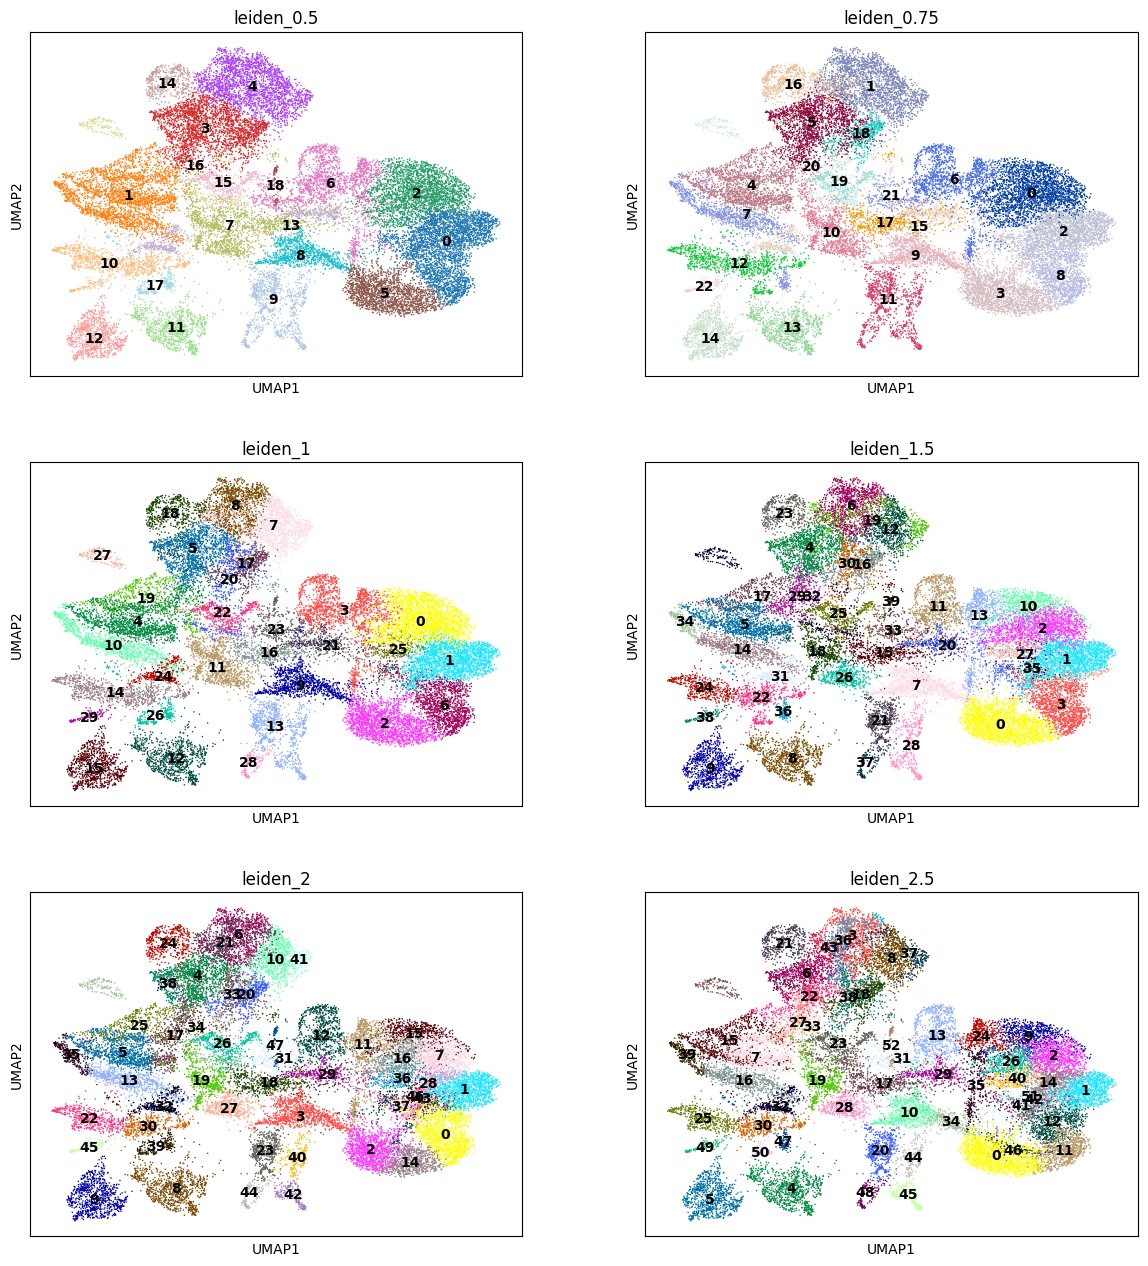

In [29]:
sc.pl.umap(ad, color=["leiden_0.5", "leiden_0.75","leiden_1", "leiden_1.5", "leiden_2","leiden_2.5"], legend_loc='on data', ncols=2)


In [30]:
ad.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,sample,sample_id,n_genes,leiden,treatment,barcode,region_annotation,leiden_0.5,leiden_0.75,leiden_1,leiden_1.5,leiden_2,leiden_2.5
AAACAAGTATCTCCCA-1-P24215_301,1,50,102,28217,34029,P24215_301,P24215_301,5333,6,BRICHOS,AAACAAGTATCTCCCA-1,NaN,6,6,3,13,11,35
AAACAGAGCGACTCCT-1-P24215_301,1,14,94,10018,31732,P24215_301,P24215_301,3317,1,BRICHOS,AAACAGAGCGACTCCT-1,NaN,1,4,4,5,17,7
AAACCGGGTAGGTACC-1-P24215_301,1,42,28,24142,12539,P24215_301,P24215_301,4982,0,BRICHOS,AAACCGGGTAGGTACC-1,NaN,0,2,1,1,1,14
AAACCGTTCGTCCAGG-1-P24215_301,1,52,42,29202,16598,P24215_301,P24215_301,6046,0,BRICHOS,AAACCGTTCGTCCAGG-1,NaN,0,8,6,3,0,11
AAACCTCATGAAGTTG-1-P24215_301,1,37,19,21611,9928,P24215_301,P24215_301,6179,0,BRICHOS,AAACCTCATGAAGTTG-1,NaN,0,2,1,1,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1-P28052_203,1,24,64,15524,23040,P28052_203,P28052_203,7233,4,PBS,TTGTTCAGTGTGCTAC-1,Putamen,4,1,7,19,41,37
TTGTTGTGTGTCAAGA-1-P28052_203,1,31,77,19072,26813,P28052_203,P28052_203,7315,4,PBS,TTGTTGTGTGTCAAGA-1,Putamen,4,1,7,19,41,37
TTGTTTCATTAGTCTA-1-P28052_203,1,60,30,33717,13124,P28052_203,P28052_203,6504,1,PBS,TTGTTTCATTAGTCTA-1,Optical Region,1,4,4,5,5,15
TTGTTTCCATACAACT-1-P28052_203,1,45,27,26128,12265,P28052_203,P28052_203,5322,1,PBS,TTGTTTCCATACAACT-1,Optical Region,1,4,4,29,17,27


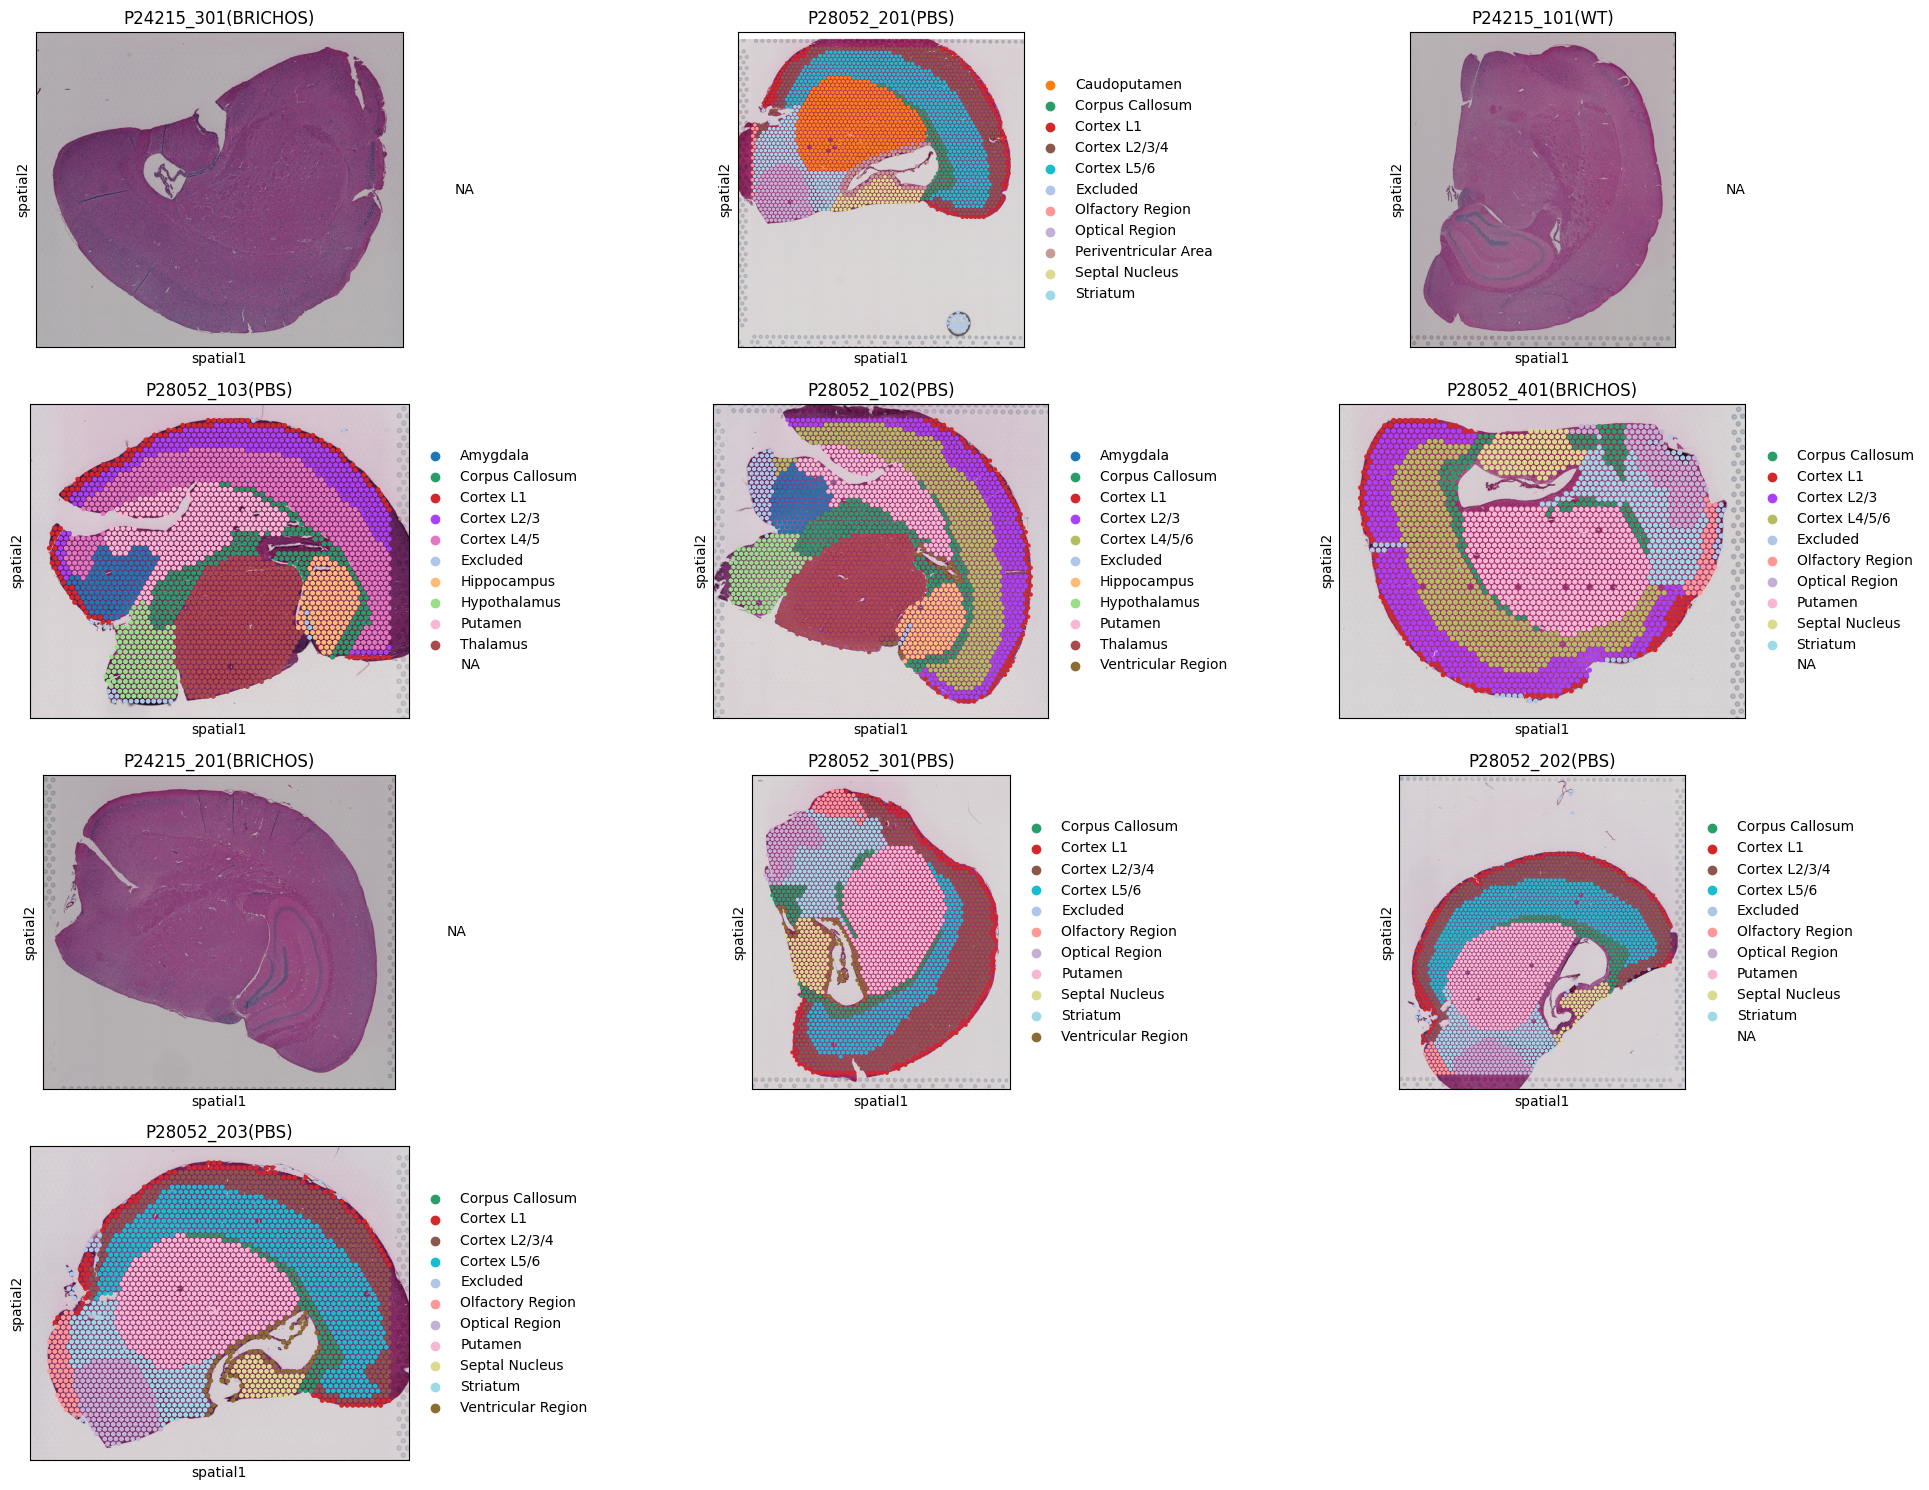

In [31]:
plot_spatial_clusters_per_sample(ad, color = 'region_annotation', figsize=(20,15))

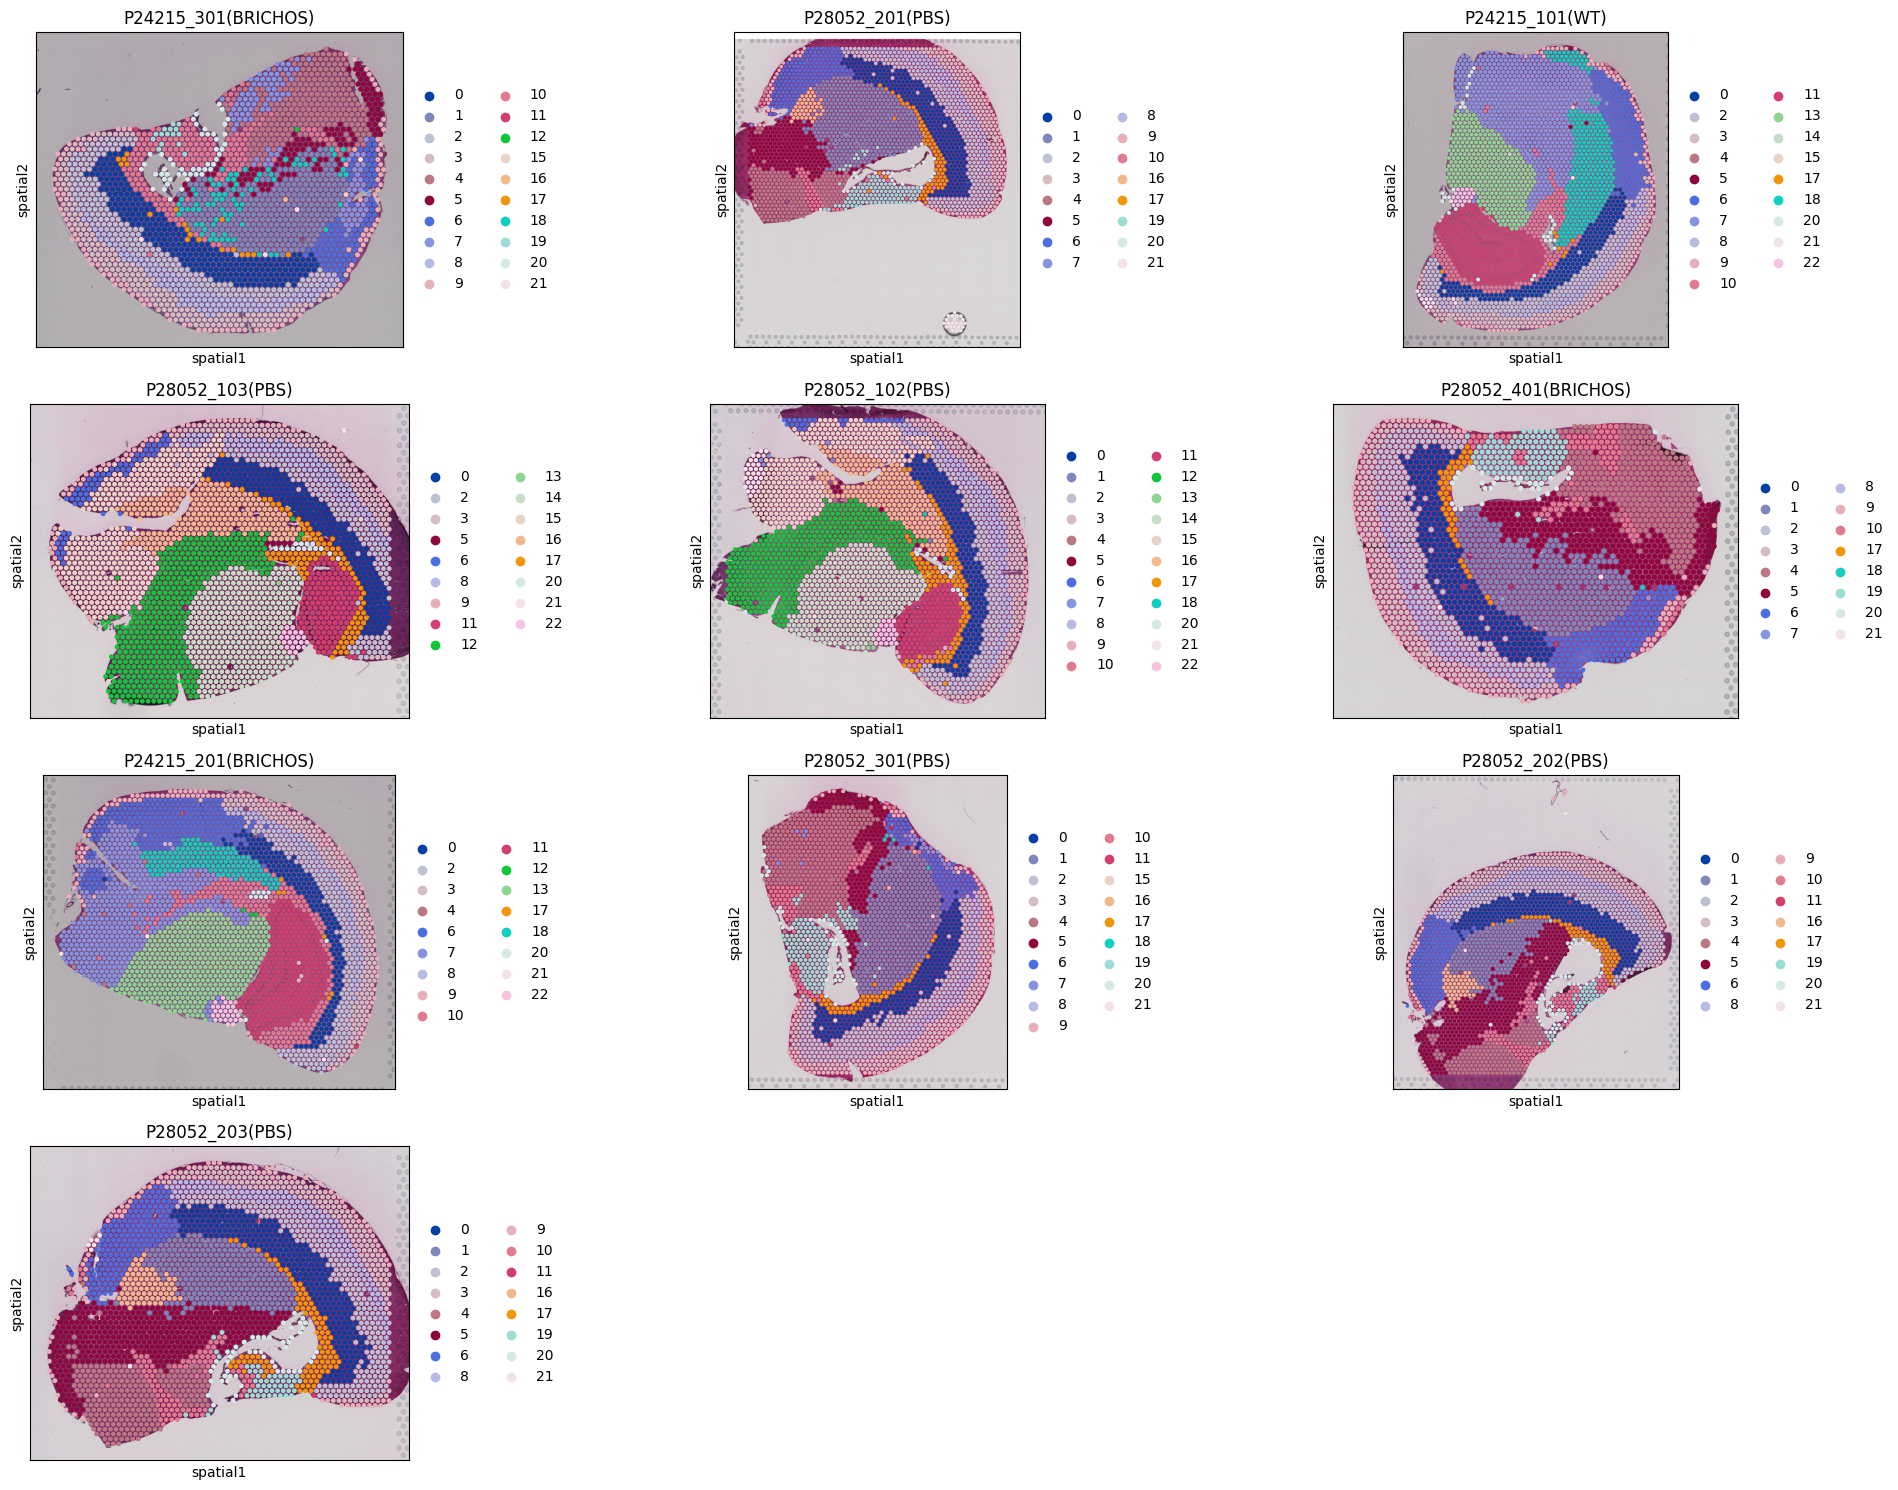

In [32]:
plot_spatial_clusters_per_sample(ad, color = 'leiden_0.75', figsize=(20,15))

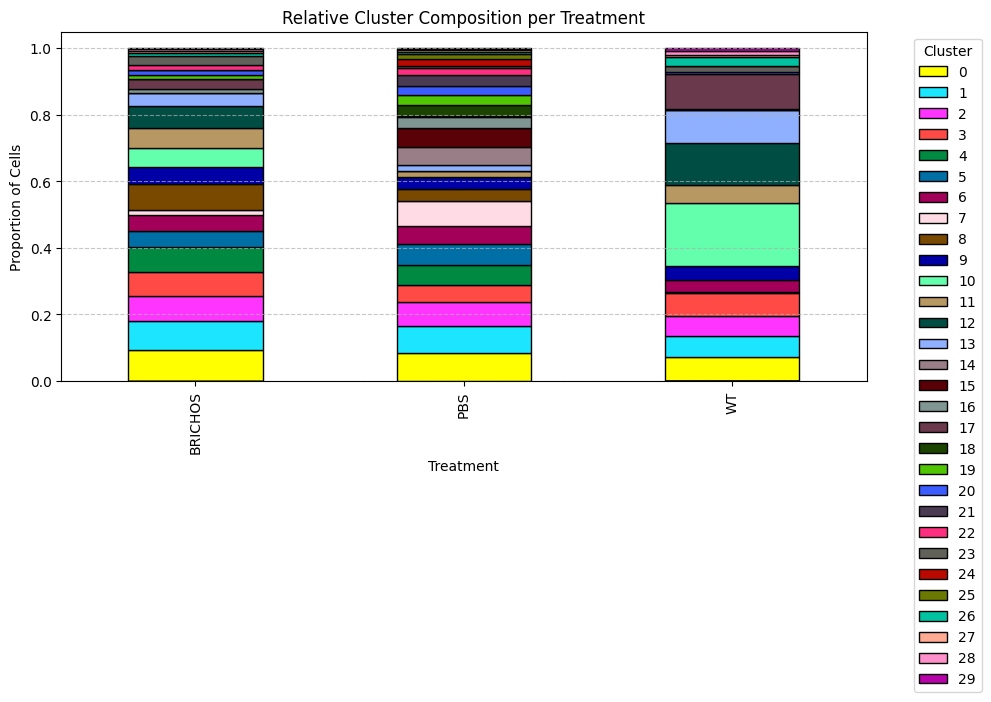

In [33]:
plot_relative_cluster_composition(ad, cluster_key="leiden_1")

In [34]:
sc.tl.rank_genes_groups(ad, groupby='leiden_0.75', method='wilcoxon')

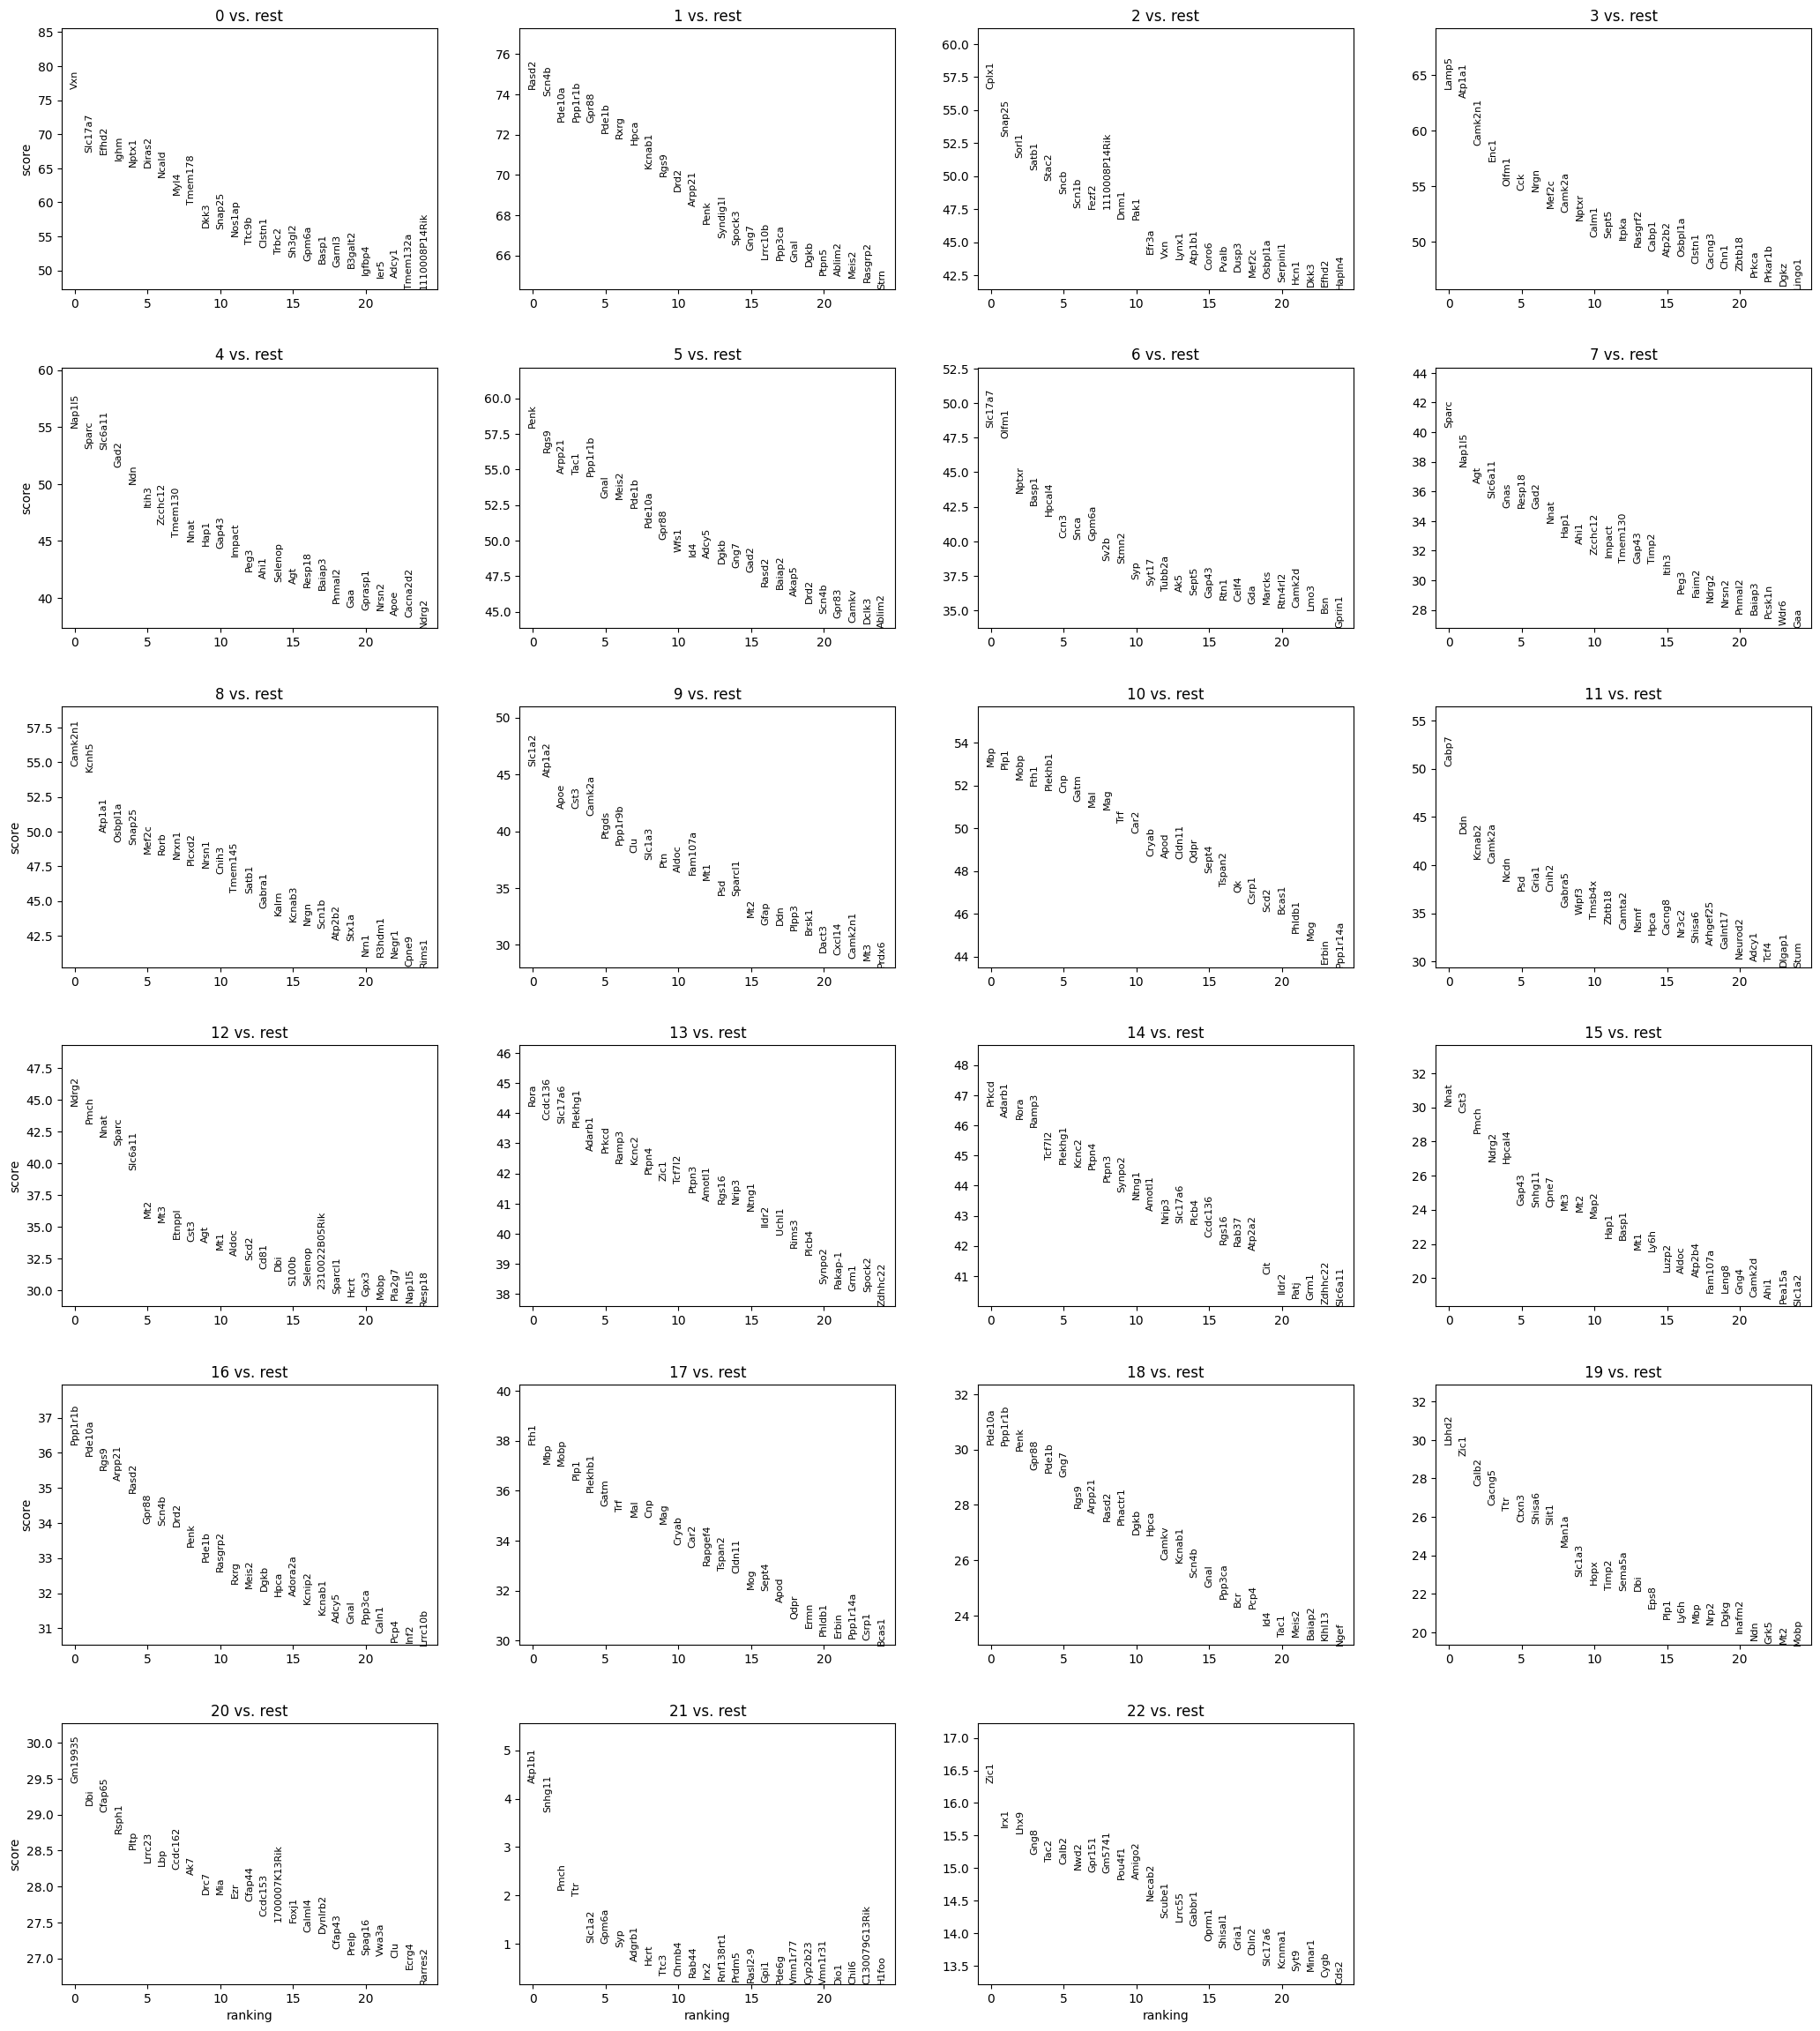

In [35]:
# See top 5 marker genes per cluster
sc.pl.rank_genes_groups(ad, n_genes=25, sharey=False)

In [36]:
marker_genes = pd.DataFrame({
    group: ad.uns['rank_genes_groups']['names'][group][:20]
    for group in ad.uns['rank_genes_groups']['names'].dtype.names
})
marker_genes.head()
#marker_genes.to_csv('../data/marker_genes.csv')

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,Vxn,Rasd2,Cplx1,Lamp5,Nap1l5,Penk,Slc17a7,Sparc,Camk2n1,Slc1a2,...,Rora,Prkcd,Nnat,Ppp1r1b,Fth1,Pde10a,Lbhd2,Gm19935,Atp1b1,Zic1
1,Slc17a7,Scn4b,Snap25,Atp1a1,Sparc,Rgs9,Olfm1,Nap1l5,Kcnh5,Atp1a2,...,Ccdc136,Adarb1,Cst3,Pde10a,Mbp,Ppp1r1b,Zic1,Dbi,Snhg11,Irx1
2,Efhd2,Pde10a,Sorl1,Camk2n1,Slc6a11,Arpp21,Nptxr,Agt,Atp1a1,Apoe,...,Slc17a6,Rora,Pmch,Rgs9,Mobp,Penk,Calb2,Cfap65,Pmch,Lhx9
3,Ighm,Ppp1r1b,Satb1,Enc1,Gad2,Tac1,Basp1,Slc6a11,Osbpl1a,Cst3,...,Plekhg1,Ramp3,Ndrg2,Arpp21,Plp1,Gpr88,Cacng5,Rsph1,Ttr,Gng8
4,Nptx1,Gpr88,Stac2,Olfm1,Ndn,Ppp1r1b,Hpcal4,Gnas,Snap25,Camk2a,...,Adarb1,Tcf7l2,Hpcal4,Rasd2,Plekhb1,Pde1b,Ttr,Pltp,Slc1a2,Tac2


In [37]:
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

0
Vxn Slc17a7 Efhd2 Ighm Nptx1 Diras2 Ncald Myl4 Tmem178 Dkk3 Snap25 Nos1ap Ttc9b Clstn1 Trbc2 Sh3gl2 Gpm6a Basp1 Garnl3 B3galt2
 
1
Rasd2 Scn4b Pde10a Ppp1r1b Gpr88 Pde1b Rxrg Hpca Kcnab1 Rgs9 Drd2 Arpp21 Penk Syndig1l Spock3 Gng7 Lrrc10b Ppp3ca Gnal Dgkb
 
2
Cplx1 Snap25 Sorl1 Satb1 Stac2 Sncb Scn1b Fezf2 1110008P14Rik Dnm1 Pak1 Efr3a Vxn Lynx1 Atp1b1 Coro6 Pvalb Dusp3 Mef2c Osbpl1a
 
3
Lamp5 Atp1a1 Camk2n1 Enc1 Olfm1 Cck Nrgn Mef2c Camk2a Nptxr Calm1 Sept5 Itpka Rasgrf2 Cabp1 Atp2b2 Osbpl1a Clstn1 Cacng3 Chn1
 
4
Nap1l5 Sparc Slc6a11 Gad2 Ndn Itih3 Zcchc12 Tmem130 Nnat Hap1 Gap43 Impact Peg3 Ahi1 Selenop Agt Resp18 Baiap3 Pnmal2 Gaa
 
5
Penk Rgs9 Arpp21 Tac1 Ppp1r1b Gnal Meis2 Pde1b Pde10a Gpr88 Wfs1 Id4 Adcy5 Dgkb Gng7 Gad2 Rasd2 Baiap2 Akap5 Drd2
 
6
Slc17a7 Olfm1 Nptxr Basp1 Hpcal4 Ccn3 Snca Gpm6a Sv2b Stmn2 Syp Syt17 Tubb2a Ak5 Sept5 Gap43 Rtn1 Celf4 Gda Marcks
 
7
Sparc Nap1l5 Agt Slc6a11 Gnas Resp18 Gad2 Nnat Hap1 Ahi1 Zcchc12 Impact Tmem130 Gap43 Timp2 Itih3 Peg3 Faim2 Ndrg2 

✅ Scored PIG module with 52 genes
✅ Scored OLIG module with 14 genes


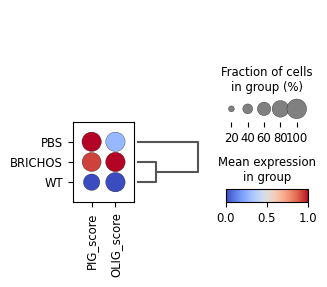

In [38]:
score_and_plot_modules(ad, modules, groupby="treatment")

✅ Scored PIG module with 52 genes
✅ Scored OLIG module with 14 genes


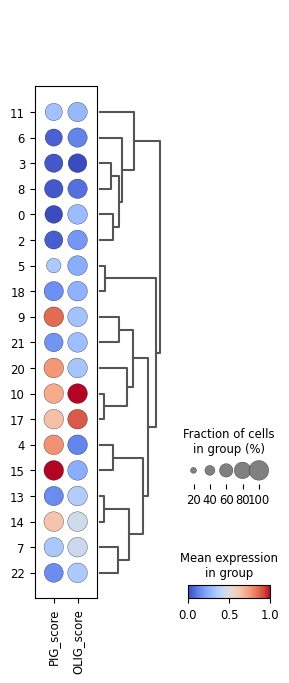

In [39]:
score_and_plot_modules(ad[ad.obs.treatment == 'WT'], modules, groupby="leiden_0.75")

✅ Scored PIG module with 52 genes
✅ Scored OLIG module with 14 genes


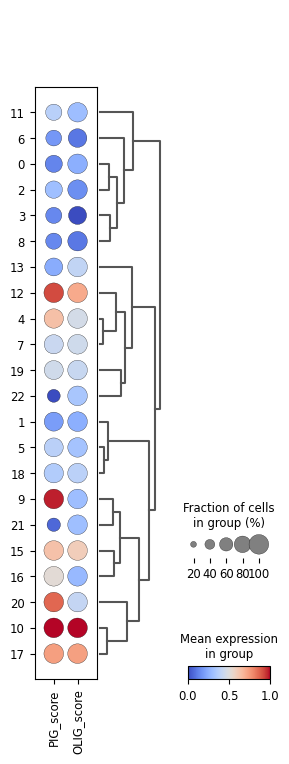

In [40]:
score_and_plot_modules(ad[ad.obs.treatment == 'BRICHOS'], modules, groupby="leiden_0.75")

In [41]:
ad.write('../data/ST_BRICHOS_region_subcluster.h5ad')

In [45]:
ad.X

array([[0.5548471 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.5959003 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.45624375, 0.        ,
        0.        ]], dtype=float32)